Given $Eu$ has no net electronic spin we have a slightly different spin Hamiltonian
$$H = \underbrace{\mu_{n}\times B\times g_{n}\times I}_{\textrm{Nuclear Zeeman}}+\underbrace{I\times Q\times I}_{Quadrupole}$$

As per [Longdell et. al.](10.1103/PhysRevB.74.195101). This work focuses on ${}^{151}Eu$, with $\frac{5}{2}$ nuclear spin, that sits in a $C_{1}$ symmetry site. Note the work uses $B\times M\times I$ for its nuclear zeeman terms so we will divide M by the nuclear magneton.

In [1]:
import numpy as np
import spin_hamiltonian as spin
from scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt
import matplotlib.colors as clr
from copy import deepcopy

In [2]:
#spin Operators of Eu:YSO:
Espin = 0#1/2
Ispin = 5/2

muNf = 7.622593285 #MHz/T
#muNf*=(1E6/1E4)*1E-3 #kHz/G

#Initialise the class with its electronic and nuclear spin, for both ground and excited state
ground = spin.cSpinHamiltonian(Espin,Ispin)

print(ground.I.shape)
print(ground.Idim,ground.Edim,ground.dim)
print(muNf)

(36, 3)
6 1 6
7.622593285


In [3]:
#M tensor ground state
M = np.matrix(np.diag([0.443,0.5682,1.1193]))*10/muNf#*muNf#*1E-4#/muNf#*1E-1#*spin.h*spin.muN
#Q tensor ground state
Q = -1*np.matrix(np.diag([-2.735,2.735,12.3797]))*1E6*spin.h #MHz*h

print(Q/(1E6*spin.h))

#rotated tensors
M_rot = np.array([144.9,34.9,98.1])*np.pi/180
Q_rot = np.array([-39.3,76.49,149.9])*np.pi/180

M_G = spin.tensorRotation(M,M_rot,str='ZYZ')
Q_G = spin.tensorRotation(Q,Q_rot,str='ZYZ')

print('Q',Q_G/(1E6*spin.h))
print('M',M_G)
#Initialise the static quadrapole interaction
ground.quadrupoleInteraction(Q_G)
ground.setgN(M_G)
#print(ground.H.shape)

[[  2.735    0.       0.    ]
 [  0.      -2.735    0.    ]
 [  0.       0.     -12.3797]]
Q [[-8.05309891  4.92442566 -0.95337412]
 [ 4.92442566 -4.93600935  3.76242426]
 [-0.95337412  3.76242426  0.60940826]]
M [[ 0.86681904 -0.17967655 -0.27127711]
 [-0.17967655  0.69749996  0.20667946]
 [-0.27127711  0.20667946  1.23066155]]


# ZEFOZ notes:
Critical points occur when:
$$\frac{\partial f_{nm}}{\partial B_{i}} = \left<\psi_{n}\right|A_{i}\left|\psi_{m}\right>=0$$

Our sensitivity is the extension:
$$\vec{S}_{1} = \frac{\partial f_{nm}}{\partial B_{x}}\vec{i}+\frac{\partial f_{nm}}{\partial B_{y}}\vec{j}+\frac{\partial f_{nm}}{\partial B_{z}}\vec{k}$$

Maximum curvature given by the largest eigenvalue of $S_{2}$
$$\vec{S}_{2} = \begin{pmatrix}\frac{\partial^2 f}{\partial B_{x}\partial B_{x}}&\frac{\partial^2 f}{\partial B_{x}\partial B_{y}}&\frac{\partial^2 f}{\partial B_{x}\partial B_{z}}\\\frac{\partial^2 f}{\partial B_{y}\partial B_{x}}&\frac{\partial^2 f}{\partial B_{y}\partial B_{y}}&\frac{\partial^2 f}{\partial B_{y}\partial B_{z}}\\\frac{\partial^2 f}{\partial B_{z}\partial B_{x}}&\frac{\partial^2 f}{\partial B_{z}\partial B_{y}}&\frac{\partial^2 f}{\partial B_{z}\partial B_{z}}\end{pmatrix}$$

Where
$$\frac{\partial^2 f}{\partial B_{i}\partial B_{j}} =\sum_{m\neq n}\frac{1}{f_{n}-f_{m}}\left[\left<\psi_{m}\right|A_{i}\left|\psi_{n}\right>\left<\psi_{n}\right|A_{j}\left|\psi_{m}\right>+c.c.\right]+G_{i,j}+G_{j,i} $$

This gives our $T_{2}$ time at a ZEFOZ point:
$$\frac{1}{\pi T_{2}} = \vec{S}_{1}\cdot\Delta\vec{B}+\Delta\vec{B}\cdot\vec{S}_{2}\cdot\Delta\vec{B}$$

In [4]:
theta,phi = spin.eulerToSphere(M_rot,str='ZXZ')
theta = 1*np.pi/2
phi=1*np.pi/2

thetas=np.pi/2*np.linspace(-1,1,45)
phis=np.pi/2*np.linspace(-1,1,45)
#Bs=np.logspace(-3,1,200)
Bs = np.linspace(0,10,100)
thetas = Bs
phis = Bs

#Bs=[0,0.1]

#thetas = [theta]
#phis = [phi]



#sets the default dynamic term as both electronic and nuclear zeeman
FreqG = ground.initSweep(thetas,phis,Bs)

OS_SG = np.zeros((len(thetas),len(phis),len(Bs),ground.dim,3),dtype = np.csingle)#
CS_G = ground.initSweep(thetas,phis,Bs,ground.dim)
#CS_G = np.zeros((len(thetas),len(phis),len(Bs),3,3))

Bac = np.matrix([1,1,1]).T

BC = np.eye(3)
#print('Q',Q_G)
Is = spin.spinOperator(Ispin,matricies=True)

As = spin.genAMatrix(spin.muN*M_G,Is)

off= np.matrix([-0.535,-0.634,0.558]).T
off = np.asmatrix(Rotation.from_euler('ZYZ',Q_rot).as_matrix())@off
print("Off: ",off,"Off mag",np.linalg.norm(off))
#off= np.matrix([0,0,0]).T

#print(As[0])
#print(As)

#our loop
for i in range(len(thetas)):
    for j in range(len(phis)):
        for k in range(len(Bs)):
            #convert spherical Magnetic field to cartesian coords.
            #unit =spin.sphereCart(1,thetas[i],phis[j])
            B = np.matrix([Bs[i],Bs[j],Bs[k]]).T
            #unit = unit/np.linalg.norm(unit)
            #unit=off
            #B = Bs[k]*unit
            
            #Calculate our hamiltonian at this B Field
            HG = ground.H+ground.nuclearZeeman(B)#/spin.muN
            #HG = H+ground.nuclearZeeman(B)#/spin.muN
            
            #get the eigen frequencies and vectors at this B field
            FG,VG = ground.getEigFreq(HG)
            FreqG[i,j,k,:]=FG*1E3
            

            #OS = np.zeros((ground.dim,3),dtype = np.csingle)
            for l in range(3):
                OS_SG[i,j,k,:,l] = ground.firstOrderEnergySensitivity(VG,As[l]/spin.muN)*spin.muN
            
            CS_G[i,j,k,:] = ground.curvatureCalculation(As[0],As[1],As[2],VG,FG)#*spin.muN
            
           
pass

Off:  [[ 0.73848249]
 [-0.24235355]
 [-0.62885083]] Off mag 0.9997724741159859


c:\Users\neb16\Documents\Uni\PHD\Experiments\Simulations\Spin_Hamiltonian\spin_hamiltonian\spin_hamiltonian.py:316: RuntimeWarning: divide by zero encountered in true_divide
  Sgn =np.nan_to_num(1/(E[a]-E[b]).reshape(self.dim,self.dim),posinf=0,nan=0,neginf=0)


Plotting of energy levels for both the ground and excited state.

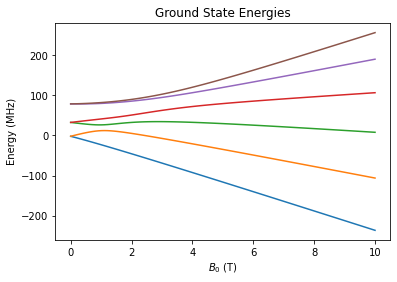

In [10]:

#Plot our energy levels
F_S = np.squeeze(np.real(FreqG[0,0,:,:]))
plt.plot(Bs,F_S)
plt.title("Ground State Energies")
plt.xlabel(r"$B_{0}$ (T)")
plt.ylabel("Energy (MHz)")
plt.savefig('../Eu',bbox_inches='tight',dpi=300)
plt.show()
plt.close()

c:\Users\neb16\AppData\Local\Programs\Python\Python39\lib\site-packages\matplotlib\cbook\__init__.py:1333: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


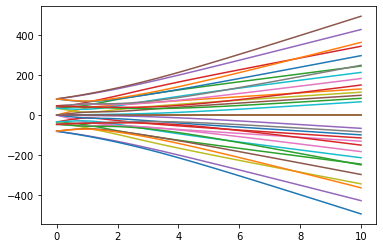

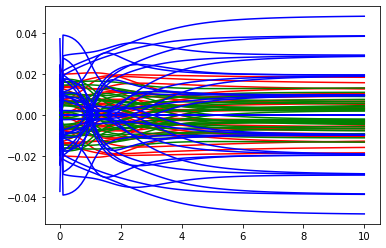

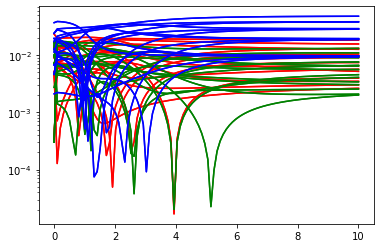

(1,)


In [6]:
Ts = spin.eachElemFunc(FreqG,FreqG,ax=3)
plt.plot(Bs,Ts[0,0,:,:])
plt.show()
plt.close()

OS = spin.eachElemFunc(OS_SG,OS_SG,ax=3)
plt.plot(Bs,np.real(OS[0,0,:,:,0]),'r')
plt.plot(Bs,np.real(OS[0,0,:,:,1]),'g')
plt.plot(Bs,np.real(OS[0,0,:,:,2]),'b')
plt.show()
plt.close()
plt.semilogy(Bs,np.abs(OS[0,0,:,:,0]),'r')
plt.semilogy(Bs,np.abs(OS[0,0,:,:,1]),'g')
plt.semilogy(Bs,np.abs(OS[0,0,:,:,2]),'b')
plt.show()
plt.close()


from scipy.signal import find_peaks

peaks,_ = find_peaks(np.abs(OS[0,0,:,1,0])) 
print(peaks.shape)


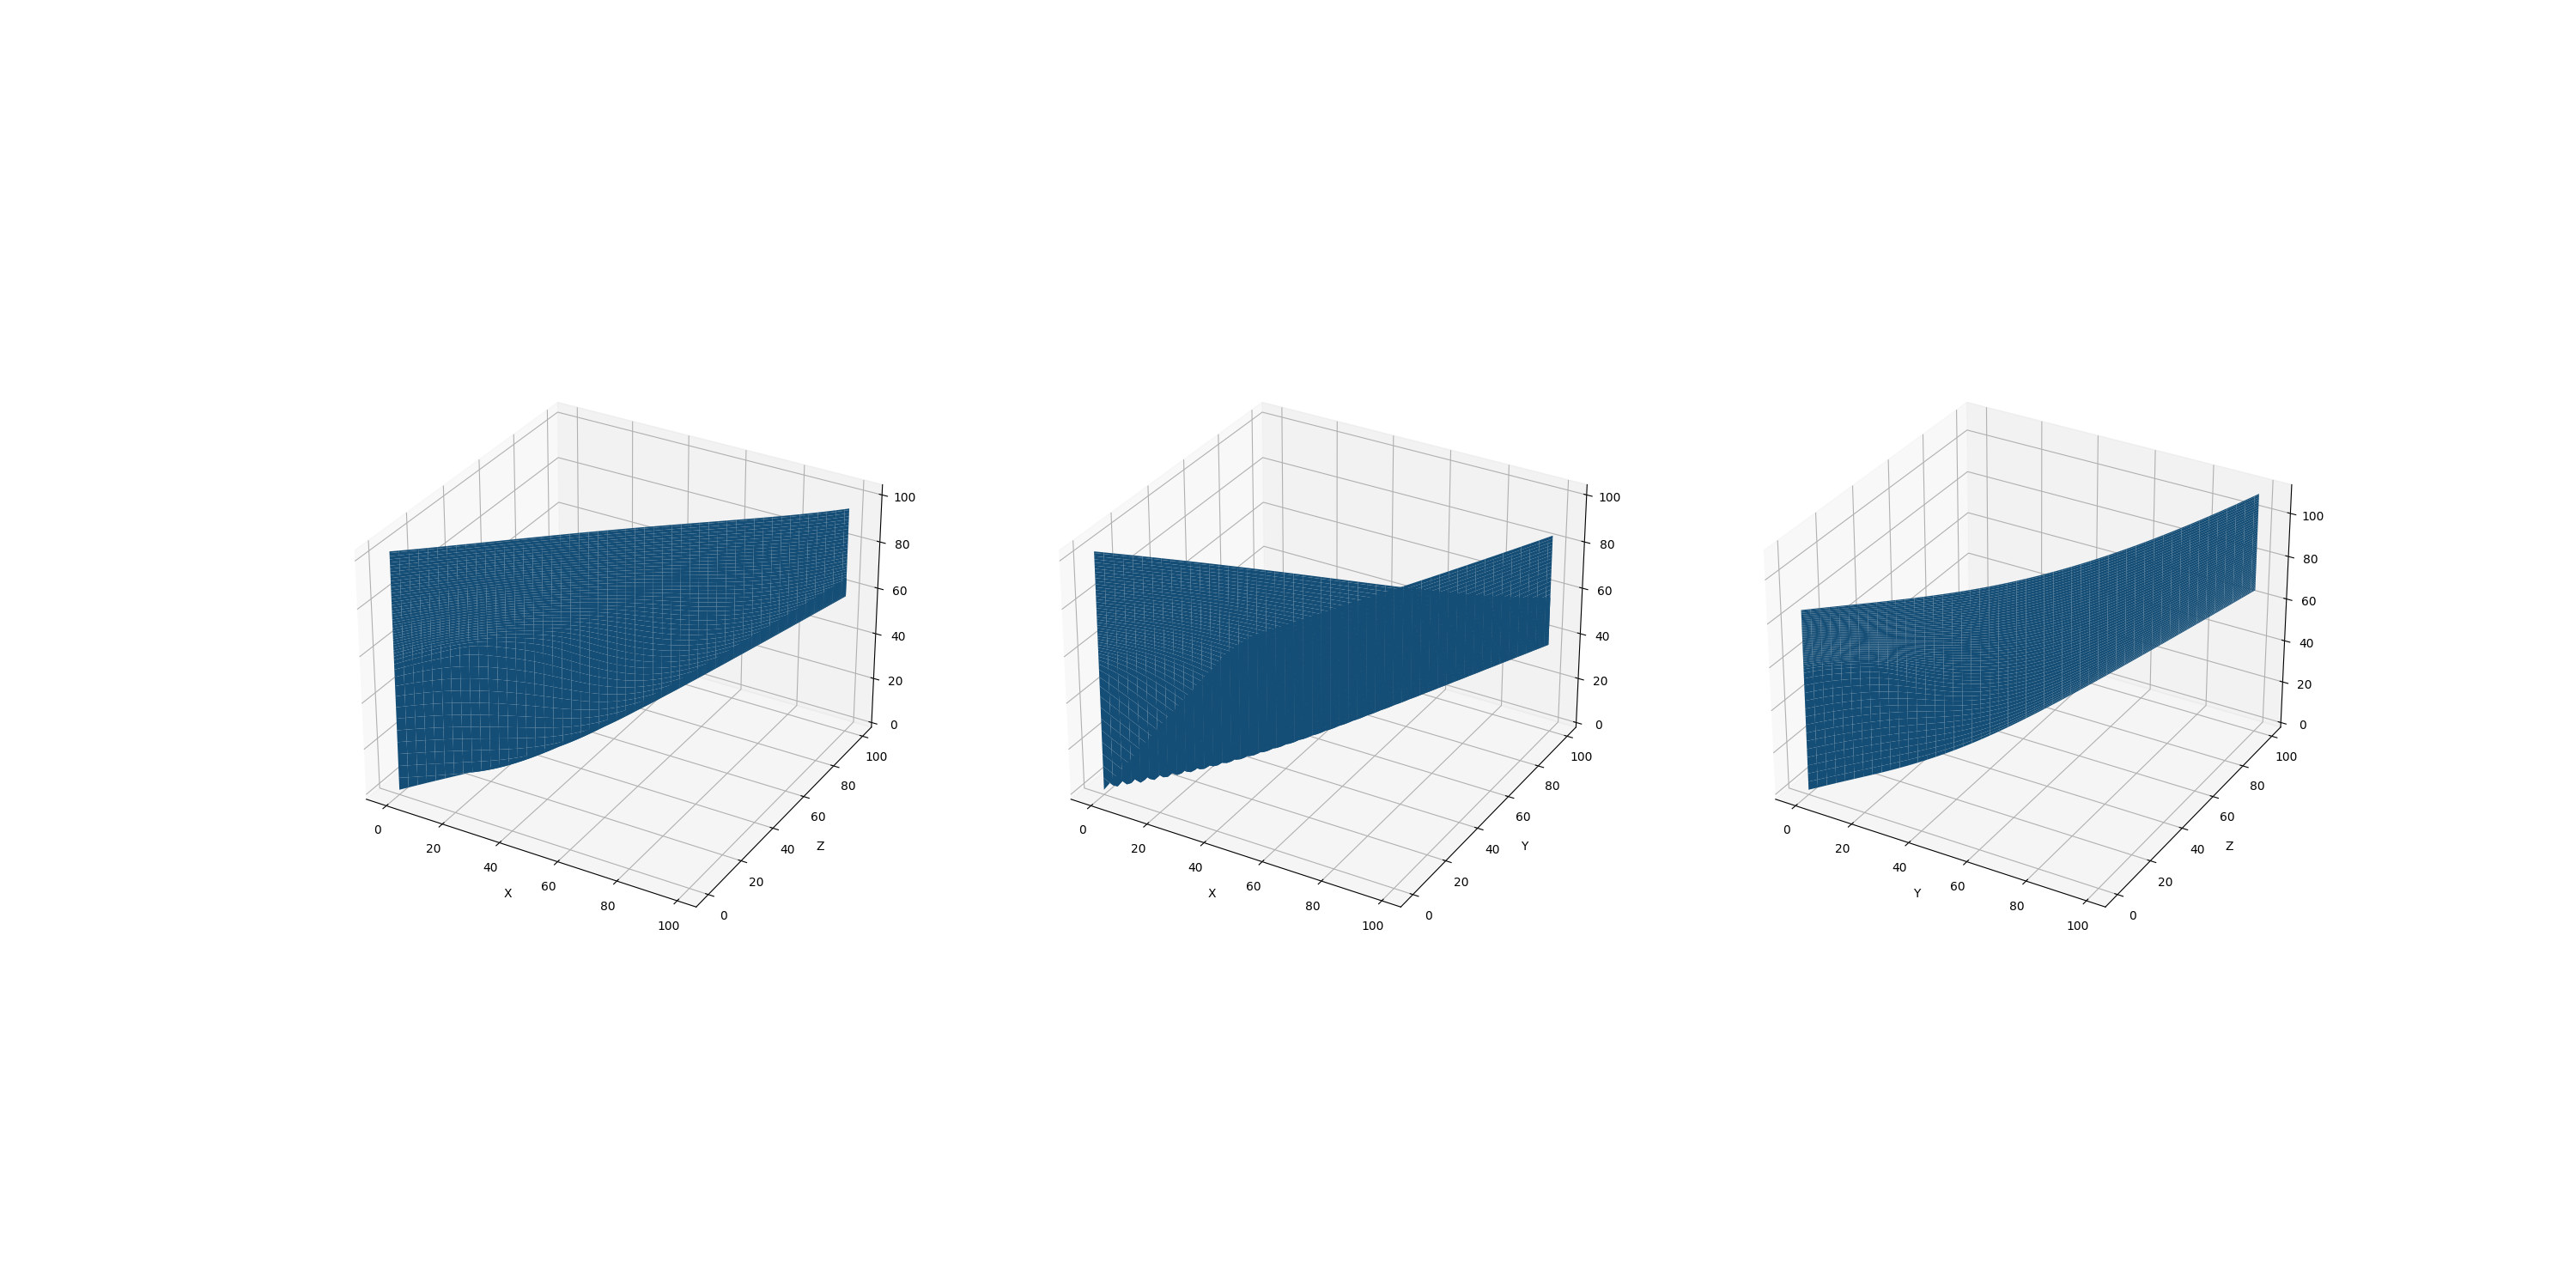

In [7]:
%matplotlib widget

Tslice = np.real(Ts[:,0,:,29])
#print(Tslice)
fig = plt.figure(figsize=(30,15))
X,Y = np.meshgrid(Bs,Bs)

#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax = plt.subplot(1,3,1,projection="3d")
ax.plot_surface(range(len(X)),range(len(Y)),Tslice)
#ax.pcolor(X,Y,Tslice)
ax.set_xlabel("X")
ax.set_ylabel("Z")
ax = plt.subplot(1,3,2,projection="3d")
ax.plot_surface(range(len(X)),range(len(Y)),np.real(Ts[:,:,0,29]))
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax = plt.subplot(1,3,3,projection="3d")
ax.plot_surface(range(len(X)),range(len(Y)),np.real(Ts[0,:,:,29]))
ax.set_xlabel("Y")
ax.set_ylabel("Z")


plt.show()
plt.close()


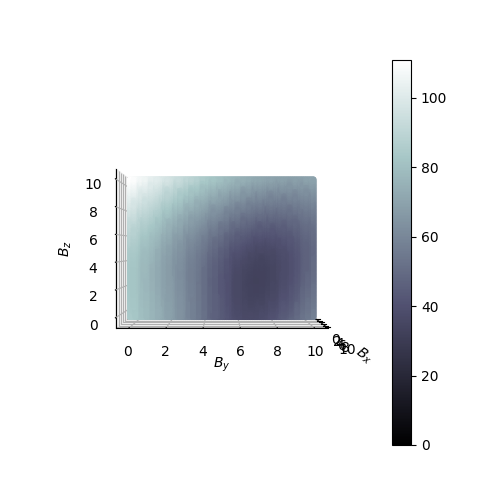

In [8]:

X,Y,Z = np.meshgrid(Bs,Bs,Bs)
fig, ax = plt.subplots(subplot_kw={"projection": "3d"},figsize=(5,5))

p=ax.scatter3D(X,Y,Z,c= np.real(Ts[:,:,:,29]),s=10,cmap='bone')
ax.view_init(elev=0., azim=0)
ax.set_xlabel("$B_{x}$")
ax.set_ylabel("$B_{y}$")
ax.set_zlabel("$B_{z}$")

fig.colorbar(p)
#ax.col
plt.show()
plt.close()
#%matplotlib inline



(527720, 5)
(2784, 4)
[0 0 0 1]
[ 1  2  3  6  8  9 11 12 13 15 16 17 18 19 20 22 23 26 27 29 31 32 33 34] [ 18   6   1  18  15   2  19   6  15   8  42  60   1   2   8 185 194  42
 185 842  19  60 194 842]
0.1
19319.161472486325


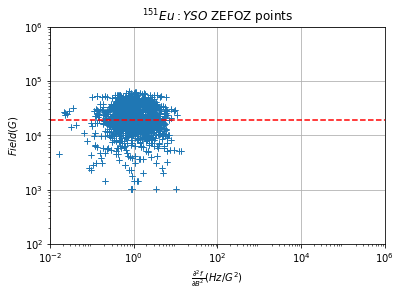

In [9]:
%matplotlib inline
#np.savez("1E-1_linear_grid",FG,OS_SG,CS_G)
ps = spin.zero_crossings(OS,2)
print(ps.shape)
id = spin.ZEFOZidx(OS,2)
CS = np.abs(spin.eachElemFunc(CS_G,CS_G,ax=3))

print(id.shape)
print(id[0])
u,c = np.unique(id[:,3],return_counts=True)

print(u,c)
print((Bs[-1]-Bs[0])/len(Bs))


B = np.sqrt(Bs[id[:,0]]**2+Bs[id[:,1]]**2+Bs[id[:,2]]**2)

C = np.array([1.77,-0.63,-0.45])
Cn =np.linalg.norm(C)*1E4
print(Cn)

plt.loglog(CS[tuple(id.T)]*1E1,B*1E4,'+')
plt.loglog(np.logspace(-2,6,10),Cn*np.ones(10),'r--')
plt.title(r'${}^{151}Eu:YSO$ ZEFOZ points')
plt.ylabel(r'$Field(G)$')
plt.xlabel(r"$\frac{\partial^2f}{\partial B^{2}}(Hz/G^2)$")
plt.xlim([1E-2,1E6])
plt.ylim([1E2,1E6])
plt.xticks([1E-2,1E0,1E2,1E4,1E6])
plt.grid()
plt.savefig("./zefoz.png")
plt.show()
plt.close()


